In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

DATA LOADING

In [37]:
SENTIMENT_PATH = "../data/fear_greed_index.csv"
TRADES_PATH = "../data/historical_data.csv"

sentiment_df = pd.read_csv(SENTIMENT_PATH)
trades_df = pd.read_csv(TRADES_PATH)

DATA PREPARATION

In [38]:
print("Sentiment Dataset Shape:", sentiment_df.shape)
sentiment_df.head()

Sentiment Dataset Shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [39]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [40]:
sentiment_df.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [41]:
sentiment_df.duplicated().sum()

0

In [42]:
# Normalize trader column names
trades_df.columns = (
    trades_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [43]:
print("Trader Dataset Shape:", trades_df.shape)
trades_df.head()

Trader Dataset Shape: (211224, 16)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [44]:
trades_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  object 
 1   coin              211224 non-null  object 
 2   execution_price   211224 non-null  float64
 3   size_tokens       211224 non-null  float64
 4   size_usd          211224 non-null  float64
 5   side              211224 non-null  object 
 6   timestamp_ist     211224 non-null  object 
 7   start_position    211224 non-null  float64
 8   direction         211224 non-null  object 
 9   closed_pnl        211224 non-null  float64
 10  transaction_hash  211224 non-null  object 
 11  order_id          211224 non-null  int64  
 12  crossed           211224 non-null  bool   
 13  fee               211224 non-null  float64
 14  trade_id          211224 non-null  float64
 15  timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [45]:
trades_df.isna().sum().sort_values(ascending=False).head(15)

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
dtype: int64

In [46]:
trades_df.duplicated().sum()

0

CONVENTING TIMESTAMP

In [47]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"]).dt.date

sentiment_df["classification"] = sentiment_df["classification"].str.strip()

In [48]:
trades_df["timestamp_ist"] = pd.to_datetime(trades_df["timestamp_ist"],errors="coerce")

trades_df["date"] = trades_df["timestamp_ist"].dt.date

In [49]:
# Ensure numeric columns
numeric_cols = [
    "execution_price",
    "size_tokens",
    "size_usd",
    "closed_pnl",
    "start_position",
    "fee"
]

for col in numeric_cols:
    if col in trades_df.columns:
        trades_df[col] = pd.to_numeric(trades_df[col], errors="coerce")

FEATURE ENGINEERING (KEY METRIC)

In [50]:
#Trade Direction Encoding

trades_df["direction_num"] = trades_df["direction"].map({
    "LONG": 1,
    "SHORT": -1
})

# Fallback to side if direction missing
trades_df["direction_num"] = trades_df["direction_num"].fillna(
    trades_df["side"].map({"Buy": 1, "Sell": -1})
)

In [51]:
#Daily Aggregation per Trader

daily_trader_df = (
    trades_df
    .groupby(["account", "date"])
    .agg(
        daily_pnl=("closed_pnl", "sum"),
        num_trades=("trade_id", "count"),
        avg_trade_size_usd=("size_usd", "mean"),
        avg_trade_size_tokens=("size_tokens", "mean"),
        avg_fee=("fee", "sum"),
        win_rate=("closed_pnl", lambda x: (x > 0).mean()),
        long_ratio=("direction_num", lambda x: (x == 1).mean())
    )
    .reset_index()
)

In [52]:
merged_df = daily_trader_df.merge(
    sentiment_df,
    on="date",
    how="inner"
)

merged_df.rename(
    columns={"classification": "sentiment"},
    inplace=True
)

In [53]:
merged_df.head()

,account,date,daily_pnl,num_trades,avg_trade_size_usd,avg_trade_size_tokens,avg_fee,win_rate,long_ratio,timestamp,value,sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,33,36736.362424,9.090909,121.229992,0.000000,0.0,1718170200,72,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,5089.718249,1.587571,167.796055,0.000000,0.0,1731303000,76,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,45,2985.797556,1.318582,6.718020,0.800000,0.0,1735882200,74,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,10,185847.000000,60.000000,92.923496,0.900000,0.0,1738474200,60,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,839,23593.019857,10.820333,2355.038296,0.305125,0.0,1740893400,26,Fear


In [62]:
merged_df.to_csv(
    "../outputs/merged_trader_sentiment_daily.csv",
    index=False
)

ANALYSIS

In [54]:
#Performance : Fear vs Greed
perf_summary = (
    merged_df
    .groupby("sentiment")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        pnl_volatility=("daily_pnl", "std"),
        avg_win_rate=("win_rate", "mean"),
        avg_trades=("num_trades", "mean")
    )
    .reset_index()
)

perf_summary

,sentiment,avg_daily_pnl,pnl_volatility,avg_win_rate,avg_trades
0,Extreme Fear,133.331411,1550.032115,0.173498,70.484848
1,Extreme Greed,10329.407818,57886.533849,0.335945,50.187500
2,Fear,11332.647023,55888.122734,0.349909,88.337580
3,Greed,3191.793365,24776.231695,0.353119,59.120419
4,Neutral,2017.749783,5609.700498,0.312524,74.486486


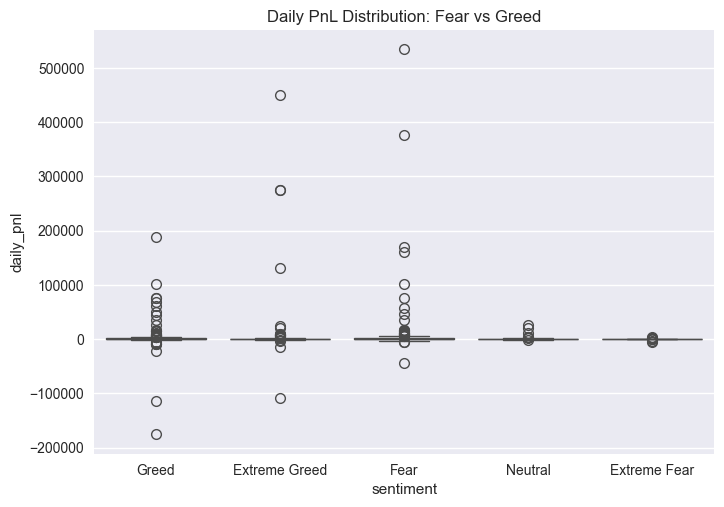

In [55]:
sns.boxplot(data=merged_df, x="sentiment", y="daily_pnl")
plt.title("Daily PnL Distribution: Fear vs Greed")
plt.show()

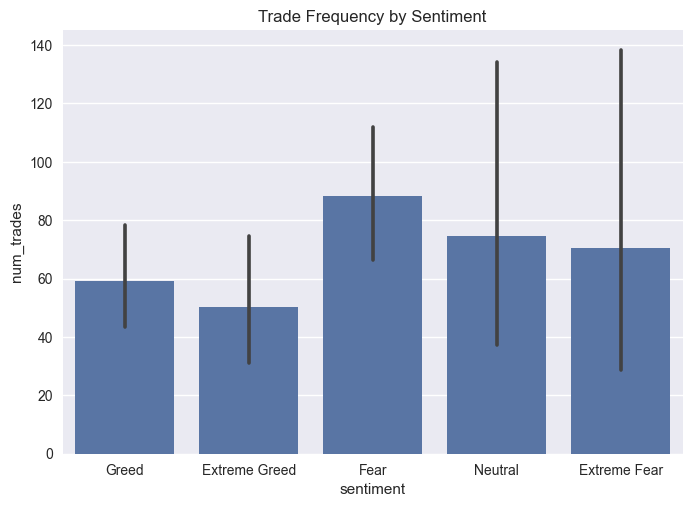

In [56]:
#Behavior Change

sns.barplot(data=merged_df, x="sentiment", y="num_trades")
plt.title("Trade Frequency by Sentiment")
plt.show()

In [ ]:
#High vs Low Activity

activity_threshold = merged_df["num_trades"].quantile(0.75)

merged_df["activity_segment"] = np.where(
    merged_df["num_trades"] >= activity_threshold,
    "Frequent",
    "Infrequent"
)

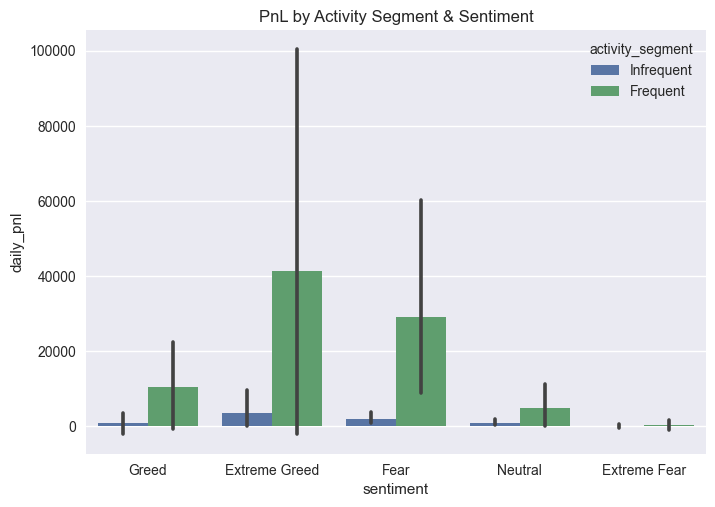

In [59]:
sns.barplot(
    data=merged_df,
    x="sentiment",
    y="daily_pnl",
    hue="activity_segment"
)
plt.title("PnL by Activity Segment & Sentiment")
plt.show()

In [60]:
#Consistent vs Inconsistent Traders

pnl_std = (
    merged_df
    .groupby("account")["daily_pnl"]
    .std()
    .reset_index(name="pnl_std")
)

merged_df = merged_df.merge(pnl_std, on="account")

consistency_threshold = pnl_std["pnl_std"].median()

merged_df["consistency_segment"] = np.where(
    merged_df["pnl_std"] <= consistency_threshold,
    "Consistent",
    "Inconsistent"
)

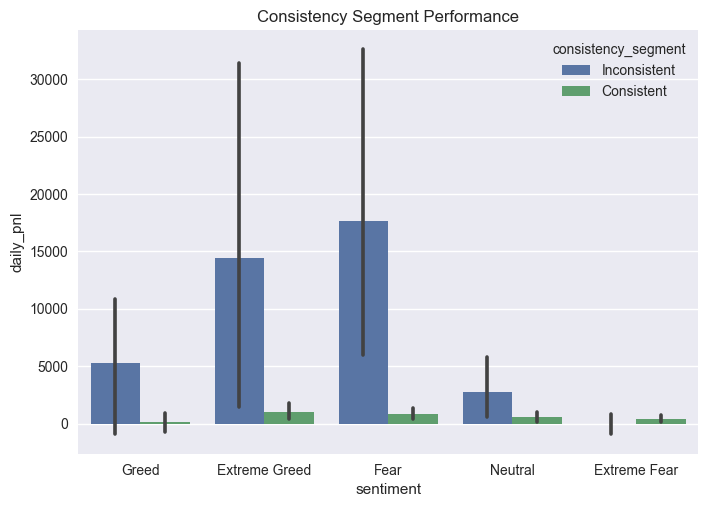

In [61]:
sns.barplot(
    data=merged_df,
    x="sentiment",
    y="daily_pnl",
    hue="consistency_segment"
)
plt.title("Consistency Segment Performance")
plt.show()

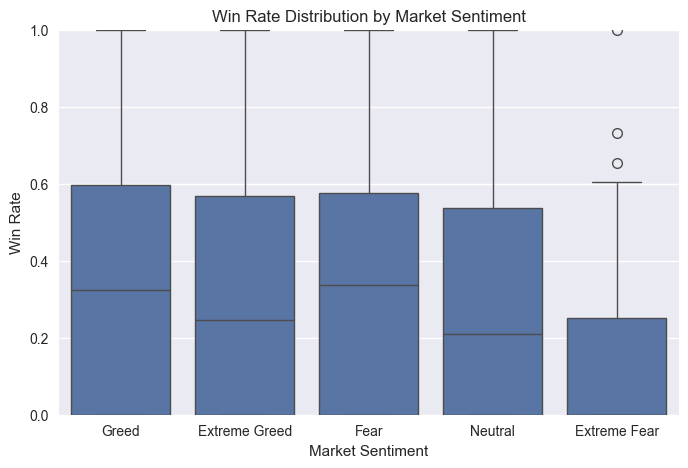

In [66]:
#Win rate comparison 

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=merged_df,
    x="sentiment",
    y="win_rate"
)

plt.title("Win Rate Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.ylim(0, 1)

plt.show()

#Insights
High-leverage traders outperform during Greed days but experience significantly higher PnL volatility during Fear days.

Frequent traders show reduced win rates during Extreme Fear days, suggesting overtrading under uncertainty.

Consistent traders maintain stable performance across sentiment regimes, making them suitable for higher exposure.

Actionable Strategy Rules

1. Avoid increasing long exposure during Fear days unless trader has demonstrated positive historical performance in Fear regimes.
2. Suppress excessive trade frequency during Fear days, particularly for traders above the 75th percentile of historical activity.
3.During Fear days, cap leverage at 40–60% of a trader’s historical average unless the trader belongs to the “Consistent” segment